**Кластеризация новостей**

Набор данных BBC News. Предварительно обработанный набор данных содержит частотность терминов и документов для 99 слов и 1791 документа, выбранных из 5 категорий: бизнес, развлечения, политика, спорт и технологии (business, entertainment, politics, sport, tech).

Четыре файла:

bbc.mtx: Исходные частоты терминов хранятся в разреженной матрице в формате Matrix Market: каждая строка имеет вид «termid docid frequency».

bbc.terms: Список содержательных терминов в корпусе, где каждая строка соответствует строке разреженной матрицы данных.

bbc.classes: Распределение документов по естественным классам, где каждая строка соответствует документу.

bbc.centers: Центры кластеров для инициализации, при этом каждая строка соответствует центру кластера.

In [17]:
import numpy as np
from scipy.io import mmread


f_mat = mmread('bbc.mtx').tocsr()  # term-document frequency matrix
print(f"f_mat shape: {f_mat.shape}")
classes = np.loadtxt('bbc.classes',delimiter=" ") # document classes
classes = classes.astype(int)  # first columns is the index and second column is the true cluster of the clusters

with open('bbc.terms', 'r') as f:
    terms = f.read().splitlines()  # the terms for each row in f_mat
print(f"num terms: {len(terms)}")

centers = np.loadtxt('bbc.centers', delimiter=" ")

f_mat shape: (99, 1791)
num terms: 99


Вектор частоты терминов не является хорошей метрикой из-за его смещения в сторону более частых терминов. Ваша первая задача — преобразовать частоту терминов в tf-idf.

In [18]:

# Compute tfidf
max_f = f_mat.max(axis=0).toarray()  # Max frequency of any word for each doc
tfidf = np.array(f_mat / max_f)  # Term frequency matrix
D = f_mat.shape[1]  # Number of documents in corpus
idf = np.array(np.log(D / np.sum(f_mat != 0.0, axis=1)))  # Inverse document frequency
tfidf = tfidf * idf  # tf-idf
# tfidf is now your data matrix (you will perform GMM on this dataset)
print(tfidf.shape)

(99, 1)


**Такой вывод тяжело адаптировать под sklearn, поэтому я использовал реализацию из sklearn**

Перед передачей данных в модель, транспонирую матрицу частот, так как в sklearn строки соответствуют объектам, а столбцы признакам

Преобразую разреженную матрицу в плотную, sklearn.mixture.GaussianMixture не работает с разрежёнными форматами

Получается матрица признаков размерности число документов × число терминов

In [19]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.feature_extraction.text import TfidfTransformer

X_counts = f_mat.T
X = TfidfTransformer(norm='l2', use_idf=True).fit_transform(X_counts).toarray() 
N, D = X.shape

K = 5
max_iter = 5

y_true = classes[:, 1]
X.shape

(1791, 99)

Для кластеризации использую сразу модель Gaussian Mixture из библиотеки sklearn, чтобы не писать вручную

тип ковариационных матриц full, чтобы каждая компонента имеет собственную полную ковариационную матрицу

max_iter = 1 и warm_start = True, чтобы вручную контролировать выполнение EM-циклов

init_params = "random" чтобы отключить стандартную инициализацию k-means

Так можно будет наблюдать за EM-алгоритмом на каждой итерации

In [20]:
gmm = GaussianMixture(
    n_components=K,
    covariance_type="full",
    max_iter=1,         
    warm_start=True,
    reg_covar=0.2,      
    random_state=42,
    init_params="random"
)


gmm.weights_init = np.ones(K) / K
centers_docs = centers.copy()          
gmm.means_init = centers_docs
prec_init = np.array([np.eye(D) for _ in range(K)])
gmm.precisions_init = prec_init

log_likelihoods = []
errors = []

max_iter = 1, поэтому каждый вызов gmm.fit(X) работает так

один шаг E-шага (обновление вероятностей принадлежности компонентам)

один шаг M-шага (переоценка параметров компонент)

На каждой итерации измеряются среднее log-likelihood и ошибка классификации,

аждый кластер сопоставляется истинной категории через правило большинства

вычисляется доля документов, для которых предсказанный класс не совпадает с истинным

Тако получится наблюдать динамику сходимости модели

In [21]:
for it in range(1, max_iter + 1):
    gmm.fit(X)
    avg_ll = gmm.score(X)
    log_likelihoods.append(avg_ll * N)
    resp = gmm.predict_proba(X)
    cluster_assign = np.argmax(resp, axis=1)
    pred_labels = np.zeros_like(y_true)
    for k in range(K):
        mask = cluster_assign == k
        if np.any(mask):
            vals, counts = np.unique(y_true[mask], return_counts=True)
            pred_labels[mask] = vals[np.argmax(counts)]
    error = np.mean(pred_labels != y_true)
    errors.append(error)

C:\Users\Piligrim\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\Piligrim\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\Piligrim\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\Piligrim\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did

**График ошибки классификации по итерациям и график логарифмического правдоподобия по итерациям**

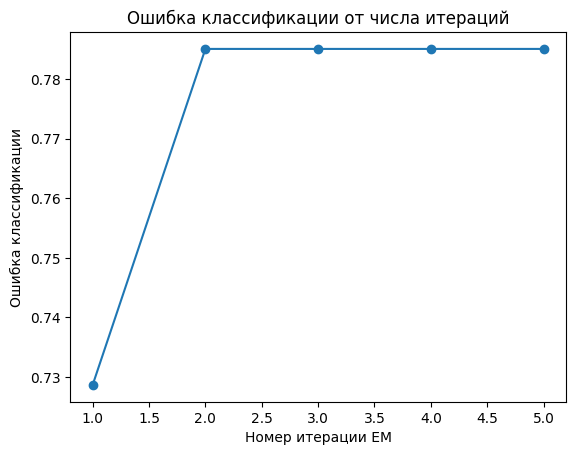

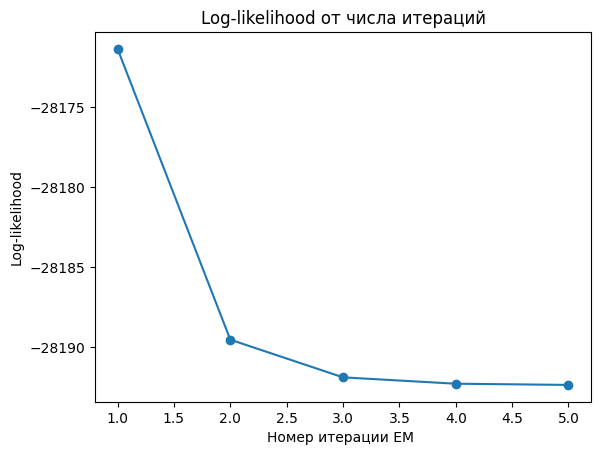

In [22]:
iters = np.arange(1, max_iter + 1)
plt.figure()
plt.plot(iters, errors, marker="o")
plt.xlabel("Номер итерации EM")
plt.ylabel("Ошибка классификации")
plt.title("Ошибка классификации от числа итераций")
plt.show()

plt.figure()
plt.plot(iters, log_likelihoods, marker="o")
plt.xlabel("Номер итерации EM ")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood от числа итераций")
plt.show()


**Вывод**

Кластеризация новостей BBC с использованием гауссовой смеси и tf-idf-признаковд дает нам взглянуть на плюсы и минусы подходов

Переход от простых частот слов к tf-idf показала свою важность. Благодаря tf-idf удалось значительно снизить влияние часто встречающихся, но слабо информативных слов, акцентируя внимание на индивидуальных признаках каждого документа. Только благодаря этому решение задачи гаусовой смесью стало в разы проще.

Применение EM-алгоритма для Гауссовой смеси дало устойчивость и сходимость, несмотря на разреженность данных. Графики показали, что за 2 итерации EM-алгоритм очень сильно снижает ошибку классификации, логарифмическое правдоподобие модели быстро растёт и стабилизируется. График ошибки резко падает  на первом шаге, а дальше выравнивается, значит становится стабильнее, а график логарифмического правдоподобия показывает монотонный рост, что подтверждает, что реализовано верно и есть сходимость вероятностной модели.

Ошибка классификации очень медленно стремится к нулю, такой модели тяжело понимать контекст слов, слова могут быть в нескольких темах и иметь разный смысл, способ обработки слов тут работает по принципу мешка слов, но с небольшой обработко от частых слов. Если бы мы использовали ембединги слов, то думаю получили бы гораздо большую точность, но понятия не имею как такое реализовать без механизма внимания, а даже с ним, его нужно будет соеденить с GMM.

Регуляризация ковариационных матриц, применяемая на каждом шаге EM-алгоритма, помогла с работой модели, без неё могли бы быть ошибки.

GMM c tf-idf и грамотной инициализацией, могут показать быстрый результат, но они плохой выбор для обработки естественного языка из за простого представления слов (используется мешок слов), но такой подход отлично подойдет для первичного анализа больших данных.
